In [1]:
import torch 
import pickle
from pathlib import Path
import faiss
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import models, transforms
from torch.utils.data import DataLoader,Dataset
from tqdm.auto import tqdm
import numpy as np

In [2]:
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [3]:
PROJECT_DIR=Path(r"C:\Users\goura\OneDrive\Desktop\image_Similarity\visual-product-search")
EMBD_DIR=PROJECT_DIR/"data"/"embeddings"
IDX_DIR=PROJECT_DIR/"data"/"faiss"

In [7]:
train_labels=np.load(EMBD_DIR/"train_labels.npy")
with open(EMBD_DIR/"train_paths.pkl","rb") as f:
    train_paths=pickle.load(f)
with open(EMBD_DIR/"test_paths.pkl","rb") as f:
    test_paths=pickle.load(f)
train_index=faiss.read_index(str(IDX_DIR/"train_index.faiss"))
test_index=faiss.read_index(str(IDX_DIR/"test_index.faiss"))
train_emnbdings=np.load(EMBD_DIR/"train_embeddings.npy")
test_emebddings=np.load(EMBD_DIR/"test_embdings.npy")
test_labels=np.load(EMBD_DIR/"test_labels.npy")


In [5]:
# Dataset_path=Path(r"C:\Users\goura\OneDrive\Desktop\image_Similarity\visual-product-search\data\raw\Stanford_Online_Products")
# train_df=pd.read_csv(Dataset_path/"Ebay_train.txt",sep=" ")
# test_df=pd.read_csv(Dataset_path /"Ebay_test.txt",sep=" ")

In [6]:
# img_transform=transforms.Compose([
#     transforms.Resize((128,128)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
# ])

In [7]:
# class dataset(Dataset):
#     def __init__(self,dataframe,dir,transform=None):
#         self.dataframe=dataframe
#         self.dir=dir
#         self.transform=transform
#     def __len__(self):
#         return len(self.dataframe)
#     def __getitem__ (self,idx):
#         row=self.dataframe.iloc[idx]
#         image_path = self.dir / row["path"]
#         images=Image.open(image_path).convert("RGB")
#         labels=row["class_id"]
#         if self.transform:
#             images=self.transform(images)
#         return images,labels,str(image_path)


In [8]:
# train_d=dataset(dataframe=train_df,dir=Dataset_path,transform=img_transform)
# test_d=dataset(dataframe=test_df,dir=Dataset_path,transform=img_transform)

In [9]:
# train_loader=DataLoader(train_d,batch_size=8,shuffle=False,num_workers=0,pin_memory=True)
# test_loader=DataLoader(test_d,batch_size=8,shuffle=False,num_workers=0,pin_memory=True)

In [10]:
# 

In [11]:
# import torch.nn as nn

In [12]:
# class FeatureExtractor(nn.Module):
#     """
#     Resnet50 Feature Extractor 
#     Convert an Iput image to 2048 embedding vectors
#     """
#     def __init__(self):
#         super().__init__()
#         self.model=models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
#         self.model.fc=nn.Identity()
#     def forward(self,x):
#         return self.model(x)
# Model=FeatureExtractor().to(device)
# Model.eval()

In [13]:
# images,labels,image_path =next(iter(test_loader))

In [14]:
# # images=images.to(device)
# labels=labels.to(device)

In [15]:
# print(images.shape)
# print(labels)

In [16]:
# test_emebddings=[]
# test_labels=[]
# test_paths=[]
# Model.eval()
# with torch.no_grad():
#     for images,labels,image_path in tqdm(test_loader):
#         images,labels=images.to(device),labels.to(device)
#         embd=Model(images)
#         test_emebddings.append(embd.cpu())
#         test_labels.extend(labels.cpu().numpy())
#         test_paths.extend(image_path)

In [17]:
# test_emebddings_1.shape

In [18]:
# import numpy

In [19]:
# test_emebddings_1=torch.cat(test_emebddings).numpy()
# test_labels_1=numpy.array(test_labels)

In [20]:
# np.save(EMBD_DIR/"test_embdings_V1",test_emebddings_1)
# # np.save(EMBD_DIR/"test_labels",test_labels_1)
# # with open(EMBD_DIR/"test_paths.pkl","wb") as f:
# #     pickle.dump(test_paths,f)

In [21]:
# test_emebddings.shape

In [22]:
# train_emnbdings=np.load(EMBD_DIR/"train_embeddings.npy")
# train_emnbdings.shape

In [8]:
# dim=train_emnbdings.shape[1]
# dim

2048

In [ ]:
# faiss.normalize_L2(train_emnbdings)
# index = faiss.IndexHNSWFlat(2048,16)
# index.add(train_emnbdings)

In [ ]:
# faiss.write_index(index,str(IDX_DIR / "train_index_v1.faiss"))

In [26]:
# import faiss

# print(faiss.__version__)
# print(test_emebddings.shape)
# print(test_emebddings.dtype)

In [27]:
# query_index=faiss.read_index(str(IDX_DIR / "test_index.faiss"))
# # query_index

In [28]:
# from collections import Counter
# label_counts=Counter(test_labels)
# len(label_counts)

In [29]:
# len(test_labels)

In [30]:
def recall_at_k(query_label, retrieved_labels) :#label_counts
    # correct = np.sum(retrieved_labels == query_label)
    # total_relevant = label_counts[query_label]
    return int(query_label in retrieved_labels)
def precision_at_k(query_labels,retrived_labels):
    """precision@K: Precision value for Top K vlaues"""
    correct=np.sum(retrived_labels==query_labels)
    precison=correct/len(retrived_labels)
    return precison

In [31]:
import time
# gpu_index = faiss.index_cpu_to_all_gpus(faiss.StandardGpuResources(),0,test_index)

In [32]:
# # dir(faiss)
# import faiss

# print(faiss.__version__)
# print(hasattr(faiss, "StandardGpuResources"))
# print(faiss.get_num_gpus())

In [33]:
k=int(input("Enter the top K value")) 
eval=[]
prec=[]
srch_itm=[]
for i in tqdm(range(len(test_labels))):
    query=test_emebddings[i].reshape(1,-1)
    start=time.perf_counter()
    dis,indic=test_index.search(query,k+1)
    end=time.perf_counter()
    retrived=test_labels[indic[0][1:]]
    eval.append(recall_at_k(test_labels[i],retrived))
    prec.append(precision_at_k(test_labels[i],retrived))
    srch_itm.append((end-start)*1000)

  0%|          | 0/60502 [00:00<?, ?it/s]

In [42]:
print(f"recall@{k}:"f"{np.mean(eval)*100:.2f}%")
print(f"precison@{k}:"f"{(np.mean(prec)*5)*100:.2f}%")
print(f"Avg_time:"f"{np.mean(srch_itm):.2f}ms")

recall@20:61.85%
precison@20:68.41%
Avg_time:0.28ms


In [35]:
# query = test_emebddings[0].reshape(1, -1)
# distances, indices = test_index.search(query, 5)
# print("Query Label:", test_labels[0])
# print("Retrieved Labels:", train_labels[indices[0]])
# print("Indices:", indices[0])

In [36]:
# print("Train labels:", np.unique(train_labels)[:10])
# print("Test labels:", np.unique(test_labels)[:10])
# print("Common labels:",len(set(train_labels).intersection(set(test_labels))))

In [37]:
# print(train_df.columns)
# print(test_df.columns)

In [44]:
k=[2,5,10,20]
r_results={}
for k in k:
    recalls=[]
    for i in range(len(test_emebddings)):
        query=test_emebddings[i].reshape(1,-1)
        distance,incdices=test_index.search(query,k+1)
        retriveds=test_labels[incdices[0][1:]]
        recalls.append(recall_at_k(test_labels[i],retriveds))
    r_results[k]=np.mean(recalls)

In [45]:
k=[2,5,10,20]
P_results={}
for k in k:
    precision=[]
    for i in range(len(test_emebddings)):
        query=test_emebddings[i].reshape(1,-1)
        distance,incdices=test_index.search(query,k+1)
        retriveds=test_labels[incdices[0][1:]]
        precision.append(precision_at_k(test_labels[i],retriveds))
        P_results[k]=np.mean(precision) 

Text(0.5, 1.0, 'Recall@k')

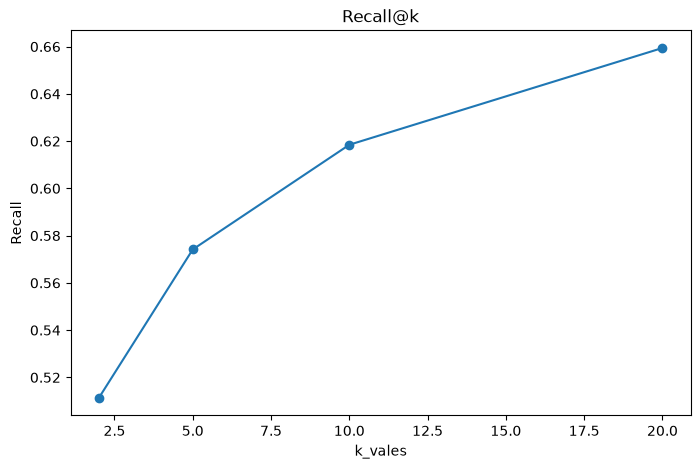

In [46]:
plt.figure(figsize=(8,5))
plt.plot(list(r_results.keys()),list(r_results.values()),marker="o")
plt.xlabel("k_vales")
plt.ylabel("Recall")
plt.title("Recall@k")

Text(0.5, 1.0, 'Precision@k')

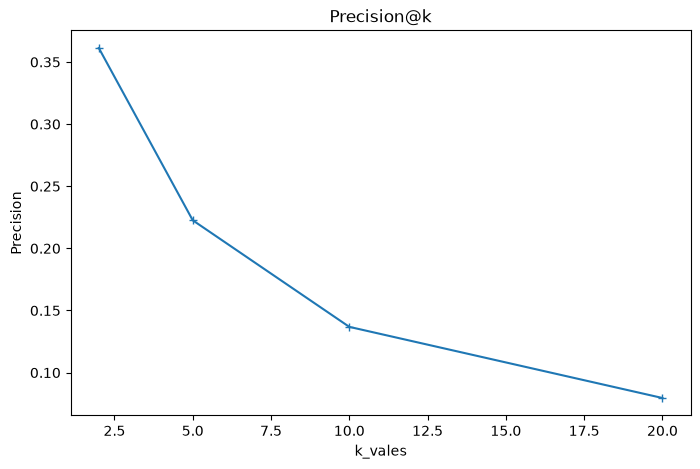

In [47]:
plt.figure(figsize=(8,5))
plt.plot(list(P_results.keys()),list(P_results.values()),marker="+")
plt.xlabel("k_vales")
plt.ylabel("Precision")
plt.title("Precision@k")